# **MÓDULO 34 - Regressão: Conceitos Avançados**

Para essa atividade vocês trabalharão com a mesma base que usamos na aula, para previsão do aluguel.

Durante a aula montamos um modelo de regressão polinomial utilizando a variavel Valor Condominio para prever a variavel valor aluguel. Nessa atividade vocês devem escolher outra váriavel dessa base para realizar a previsão do valor do aluguel.


# 1 - Realize a importação das bibliotecas necessárias, carrega a base de dados e separe em X e Y, selecionando uma das váriaveis para X não sendo a usada durante a aula.

In [4]:
#seu código aqui
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


In [7]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


In [10]:
y = df['Valor_Aluguel']

In [36]:
X = df[['Metragem']]

# 2 - Faça o procecssamento dos dados utilizando o Polynomial Feature, com degree = 2.

In [37]:
#seu código aqui
poly_features = PolynomialFeatures(degree=2)

# 3 - Separe os dados em treino e teste e realize o treinamento do modelo.

In [38]:
#seu código aqui
X_poly = poly_features.fit_transform(X)

In [39]:
X_poly

array([[1.0000e+00, 4.8000e+01, 2.3040e+03],
       [1.0000e+00, 5.0000e+01, 2.5000e+03],
       [1.0000e+00, 4.0000e+01, 1.6000e+03],
       ...,
       [1.0000e+00, 2.6600e+02, 7.0756e+04],
       [1.0000e+00, 6.0000e+02, 3.6000e+05],
       [1.0000e+00, 2.4800e+02, 6.1504e+04]], shape=(7203, 3))

In [40]:
X_train, X_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=0)

In [41]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 4 - Faça as previsões para a base de teste e avalie os resultados obtidos, não se esqueça de plotar o gráfico da regressão.

Os pontos vermelhos representam os imóveis reais: no eixo X está a metragem e no eixo Y o valor do aluguel. Dá pra ver que, em geral, quanto maior o imóvel, maior o aluguel. Porém, há bastante variação, ou seja, imóveis com a mesma metragem podem ter preços bem diferentes.
A linha azul é o modelo polinomial, que tenta mostrar a tendência dos dados. Ela indica que o aluguel aumenta com a metragem, mas não em linha reta. No começo, aumentar a metragem faz o preço subir mais rápido. Depois, esse aumento vai ficando mais lento, até chegar em um ponto em que cresce bem menos. Isso mostra que a metragem influencia o valor do aluguel, mas sozinha não explica tudo. Outros fatores também impactam no preço.

In [42]:
#seu código aqui
print("Tamanho de x_test:", X_test.shape)
print("Tamanho de y_test:", y_test.shape)


Tamanho de x_test: (1441, 3)
Tamanho de y_test: (1441,)


In [43]:
y_pred = model.predict(X_test)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


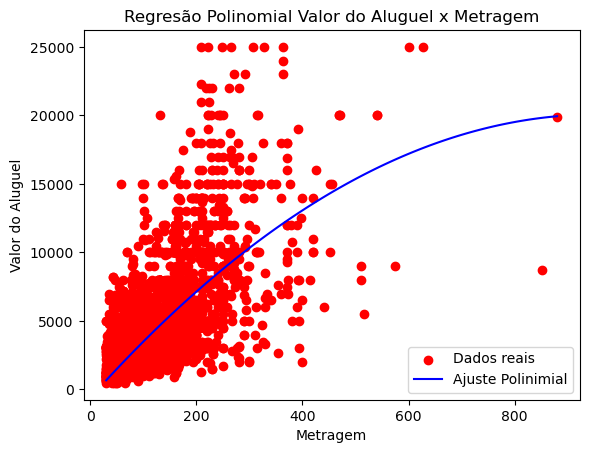

In [44]:
# CriarEmos uma sequência de valores X para a visualização, buscando a suavização
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.scatter(X, y, color ='red', label='Dados reais')
plt.plot(X_range, y_range_pred, color='blue', label='Ajuste Polinimial')
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regresão Polinomial Valor do Aluguel x Metragem')
plt.legend()
plt.show()


In [45]:
r2 = r2_score(y_test, y_pred)
print(f'R² da Regressão Polinomial: {r2:.4f}')

R² da Regressão Polinomial: 0.5423


# 5 - Refaça os passos anteriores, rodando um novo modelo, porém testando agora na fase de processamento o degree = 4. Avalie se o resultado desse novo modelo está superior ao anterior.

Comparando os modelos:
Grau 2: R² = 0,5423
Grau 4: R² = 0,5596

O modelo de grau 4 é um pouco melhor, mas a diferença é pequena (cerca de 0,017). Ou seja, o ganho foi mínimo. Pelo gráfico, a curva do grau 4 apresenta oscilações (sobe, desce e sobe novamente), o que não faz muito sentido para esse tipo de relação. Isso pode indicar overfitting, quando o modelo se ajusta demais aos dados e acaba captando ruídos. Assim, apesar de ter um R² maior, o modelo de grau 4 não traz uma melhoria significativa. Na prática, o modelo de grau 2 pode ser mais adequado por ser mais simples, mais fácil de interpretar e ter menor risco de overfitting.

In [64]:
y_4 = df['Valor_Aluguel']

In [65]:
X_4 = df[['Metragem']]

In [66]:
#seu código aqui
poly_features_4 = PolynomialFeatures(degree=4)

In [67]:
X_poly_4 = poly_features_4.fit_transform(X_4)

In [68]:
X_poly_4

array([[1.00000000e+00, 4.80000000e+01, 2.30400000e+03, 1.10592000e+05,
        5.30841600e+06],
       [1.00000000e+00, 5.00000000e+01, 2.50000000e+03, 1.25000000e+05,
        6.25000000e+06],
       [1.00000000e+00, 4.00000000e+01, 1.60000000e+03, 6.40000000e+04,
        2.56000000e+06],
       ...,
       [1.00000000e+00, 2.66000000e+02, 7.07560000e+04, 1.88210960e+07,
        5.00641154e+09],
       [1.00000000e+00, 6.00000000e+02, 3.60000000e+05, 2.16000000e+08,
        1.29600000e+11],
       [1.00000000e+00, 2.48000000e+02, 6.15040000e+04, 1.52529920e+07,
        3.78274202e+09]], shape=(7203, 5))

In [69]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_poly_4, y_4, test_size=0.2, random_state=0)

In [71]:
# Aplicando regressão linear nos dados transformados
model = LinearRegression()
model.fit(X_train_4, y_train_4)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
print("Tamanho de x_test:", X_test_4.shape)
print("Tamanho de y_test:", y_test_4.shape)

Tamanho de x_test: (1441, 5)
Tamanho de y_test: (1441,)


In [73]:
y_pred_4 = model.predict(X_test_4)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


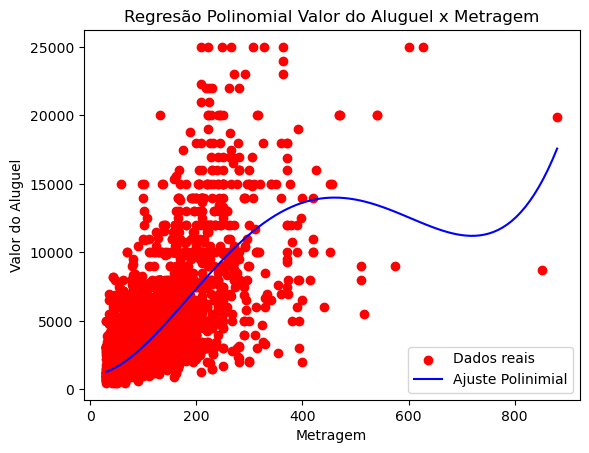

In [74]:
# CriarEmos uma sequência de valores X para a visualização, buscando a suavização
X_range_4 = np.linspace(X_4.min(), X_4.max(), 100).reshape(-1, 1)
X_range_poly_4 = poly_features_4.transform(X_range_4)
y_range_pred_4 = model.predict(X_range_poly_4)

plt.scatter(X_4, y_4, color ='red', label='Dados reais')
plt.plot(X_range_4, y_range_pred_4, color='blue', label='Ajuste Polinimial')
plt.xlabel('Metragem')
plt.ylabel('Valor do Aluguel')
plt.title('Regresão Polinomial Valor do Aluguel x Metragem')
plt.legend()
plt.show()

In [76]:
r2_4 = r2_score(y_test_4, y_pred_4)
print(f'R² da Regressão Polinomial: {r2_4:.4f}')

R² da Regressão Polinomial: 0.5596


# 6 - Explique com suas palavras o conceito e a diferença entre Elastic Net, Ridge e Lasso.
Minimo: 4 linhas.

O Lasso utiliza a penalização L1, que pode zerar os coeficientes e, assim, eliminar variáveis que não são úteis para o modelo. O Ridge utiliza a penalização L2, que reduz os coeficientes, mas não os zera. Ou seja, ele mantém todas as variáveis, apenas diminuindo sua influência. Já o Elastic Net combina L1 e L2, unindo as características do Lasso e do Ridge. Assim, ele pode tanto reduzir quanto eliminar variáveis, dependendo do caso. Essas técnicas ajudam a evitar overfitting e tornam o modelo mais estável e generalizável.
